# Case 1: Predicting Features of Returns

## Set-up

Imagine you work on an analytics team at an asset management firm.

The firm trades a portfolio of equities each day.

In this case, you'll work with a panel of daily equity returns (many tickers over time). For simplicity, you'll focus on one ticker of your choice and build and evaluate some predictive models for features of daily equity returns.

In [35]:
!pip install arch # Necessary on google colab as the arch library is not installed by default

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from joblib import Parallel, delayed
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
from matplotlib.dates import MonthLocator, DateFormatter
from sklearn.decomposition import PCA, FactorAnalysis
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import log_loss
from scipy.stats import norm

## Constructing the Return Matrix

Before we can build any predictive model, we need to put the return data into a form that is usable for time-series machine learning.

In the raw data, returns typically appear in a “long” format: Each row corresponds to a particular date and a particular asset (ticker), along with that asset's return on that date. While this format is convenient for storage, it is not the most convenient format for modeling.

We thus start by contructing a **return matrix**.



In [36]:
#Config

startdate = '2011-01-01' # This can be updated as needed ( Minimum date is 2011-01-01 as per the data available )
enddate = '2024-12-31'  # This can be updated as needed ( Maximum date is 2024-12-31 as per the data available )

In [37]:
# Import data from dropbox
!wget -O df_factor.csv https://www.dropbox.com/scl/fi/glm90k03u7yehadyw9dk5/df_factor.csv?rlkey=iwhnsi7sf9ogsvfpm9jltqzew&dl=0

df = pd.read_csv('df_factor.csv', parse_dates=['date'])

tic_list= df.loc[df['date'] < startdate, 'tic'].unique()

df = df[df['tic'].isin(tic_list[:100])]

df

--2026-03-04 21:57:45--  https://www.dropbox.com/scl/fi/glm90k03u7yehadyw9dk5/df_factor.csv?rlkey=iwhnsi7sf9ogsvfpm9jltqzew
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc536de08ed84e1b33f6beaa2718.dl.dropboxusercontent.com/cd/0/inline/C8De1qZ7PB2RAG6BkuNnhghB5nxEjLqkDu2qmb_KSqlTV3B2xjkyThVxl_bK_zr3spkw-jWv8JKSggbMD2AkSAZShvRuW3545N53F4X3fp0oYb2ZrlmDLa2Z_W4LqX4GUQ-nfwnKwHHwHkB6Rfs-zCrb/file# [following]
--2026-03-04 21:57:46--  https://uc536de08ed84e1b33f6beaa2718.dl.dropboxusercontent.com/cd/0/inline/C8De1qZ7PB2RAG6BkuNnhghB5nxEjLqkDu2qmb_KSqlTV3B2xjkyThVxl_bK_zr3spkw-jWv8JKSggbMD2AkSAZShvRuW3545N53F4X3fp0oYb2ZrlmDLa2Z_W4LqX4GUQ-nfwnKwHHwHkB6Rfs-zCrb/file
Resolving uc536de08ed84e1b33f6beaa2718.dl.dropboxusercontent.com (uc536de08ed84e1b33f6beaa2718.dl.dropboxusercontent.com)... 162.125.1.15, 2620:

,Unnamed: 0,date,tic,prcod,prchd,prcld,prccd,vol,ret,cshoc
0,3774,2010-01-04,MSFT,30.62,31.1000,30.590,30.950,38564668.0,0.015420,8.879121e+09
1,3775,2010-01-05,MSFT,30.85,31.1000,30.640,30.960,49900508.0,0.000323,8.879121e+09
2,3776,2010-01-06,MSFT,30.88,31.0800,30.520,30.770,58338993.0,-0.006137,8.879121e+09
3,3777,2010-01-07,MSFT,30.63,30.7000,30.190,30.452,50712549.0,-0.010335,8.879121e+09
4,3778,2010-01-08,MSFT,30.28,30.8800,30.240,30.660,51358330.0,0.006830,8.879121e+09
...,...,...,...,...,...,...,...,...,...,...
553678,2048467,2024-12-24,REG,73.26,74.5500,73.260,74.500,340646.0,0.010170,1.815050e+08
553679,2048468,2024-12-26,REG,74.12,74.7306,73.895,74.610,452283.0,0.001477,1.815050e+08
553680,2048469,2024-12-27,REG,74.36,74.8800,73.770,73.950,792491.0,-0.008846,1.815050e+08
553681,2048470,2024-12-30,REG,73.64,73.7000,72.870,73.410,971302.0,-0.007302,1.815050e+08


In [38]:
df = df[['date', 'tic', 'ret']]

In [39]:
df.sort_values('date', inplace=True)

/tmp/ipykernel_304/2566996094.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values('date', inplace=True)


In [40]:
returns_matrix = df.pivot(index='date', columns='tic', values='ret')
returns_matrix = returns_matrix.dropna()

In [41]:
returns_matrix = returns_matrix.loc[startdate:enddate]

In [42]:
returns_matrix

tic,AAON,AAPL,ADBE,ADI,ADP,AEP,AMAT,AMD,AMGN,APA,...,TTEK,TXN,VRTX,VTRS,WBA,WDC,WEN,XEL,XRAY,ZBRA
date,,,,,,,,,,,,,,,,,,,,,
2011-01-03,0.028359,0.021732,0.016569,0.007433,0.016638,0.007504,0.000712,0.035452,0.011840,0.015097,...,0.011971,0.007077,0.027405,0.025083,0.009240,0.007080,-0.002164,0.000425,0.027217,0.005528
2011-01-04,-0.031369,0.005219,0.007031,-0.011331,-0.003613,0.007172,-0.006401,0.035419,0.021602,0.006858,...,-0.027208,-0.001833,-0.013893,-0.005309,0.008393,-0.033685,-0.010846,0.004245,-0.011111,-0.009424
2011-01-05,0.005338,0.008180,0.022533,0.002132,0.015998,-0.015064,-0.015032,0.015963,-0.000352,0.025029,...,-0.010539,0.003979,0.038039,0.006730,0.013871,-0.006062,0.002193,-0.005917,0.009507,-0.001057
2011-01-06,-0.011327,-0.000808,0.001552,0.005585,0.007768,0.005006,0.009448,-0.024691,-0.003173,-0.020255,...,-0.009013,0.013720,-0.017372,0.035500,0.002985,0.006709,0.017506,-0.000850,-0.005708,-0.008466
2011-01-07,-0.041890,0.007161,-0.007127,-0.005819,0.002292,-0.003874,0.005040,0.016111,0.007560,0.006455,...,-0.017776,-0.000902,-0.001105,-0.006233,-0.005952,0.000606,-0.019355,0.008936,-0.004018,0.003202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.001867,0.011478,0.002686,0.014891,0.007853,-0.005277,0.005434,0.013563,0.001856,0.012500,...,0.001757,0.012096,0.007180,-0.007206,-0.011828,0.002274,0.009102,0.007236,-0.002639,0.012262
2024-12-26,-0.006157,0.003176,0.004956,-0.000138,0.002597,-0.003356,-0.004870,-0.009740,-0.004953,-0.001372,...,0.008020,-0.003690,0.006051,0.012903,0.053319,0.000162,-0.003007,-0.000440,0.013757,0.003566
2024-12-27,-0.010271,-0.013242,-0.008175,-0.004907,-0.003533,0.004888,-0.004297,0.001040,-0.002014,0.011447,...,-0.009697,-0.002869,-0.004602,-0.006370,-0.006198,-0.016367,-0.004825,-0.000587,-0.003131,-0.019604


## Set-up Questions

---

**Question 1.** Provide a brief explanation of what the code blocks above are doing. Importantly, what does the `pivot` step accomplish? After this step, what does each row represent and what does each column represent?

What does the `dropna` step accomplish? Why is this step potentially important? Does the presence of this step raise any concerns? Explain.

---

Here we look a little more at the data. We specifically look at the asset `AAPL`. You may choose to alter this to a different ticker (or tickers) if you wish. The tickers for the assets we have data on are provided by executing the first code block below.

In [43]:
returns_matrix.columns

Index(['AAON', 'AAPL', 'ADBE', 'ADI', 'ADP', 'AEP', 'AMAT', 'AMD', 'AMGN',
       'APA', 'AVT', 'BIIB', 'BOKF', 'BPOP', 'CACC', 'CAR', 'CASY', 'CBSH',
       'CDNS', 'CGNX', 'CHDN', 'CHTR', 'CINF', 'COKE', 'COO', 'CPB', 'CRUS',
       'CSCO', 'CSX', 'CTAS', 'EA', 'EVRG', 'EXC', 'FAST', 'FCNCA', 'FITB',
       'GEN', 'GILD', 'GNTX', 'HAS', 'HBAN', 'HOLX', 'HON', 'HST', 'IDXX',
       'INTC', 'INTU', 'IONS', 'JBHT', 'KLAC', 'KMB', 'LFUS', 'LIN', 'LNT',
       'LNW', 'LPLA', 'LRCX', 'LSCC', 'LSTR', 'MAT', 'MCHP', 'MIDD', 'MSFT',
       'MTCH', 'MU', 'NDSN', 'NTRS', 'NWL', 'ODFL', 'OLED', 'ORLY', 'PARA',
       'PAYX', 'PCAR', 'PEP', 'PTC', 'QCOM', 'REG', 'REGN', 'RGEN', 'RGLD',
       'ROP', 'SBUX', 'SEIC', 'SNPS', 'SWKS', 'TECH', 'TER', 'TRMB', 'TROW',
       'TTEK', 'TXN', 'VRTX', 'VTRS', 'WBA', 'WDC', 'WEN', 'XEL', 'XRAY',
       'ZBRA'],
      dtype='object', name='tic')

In [54]:
target_asset = 'AAPL' # This can be updated as needed

returns = returns_matrix[target_asset].copy()

# Summary statistics
returns.describe()

,AAPL
count,3515.000000
mean,0.001076
std,0.017610
min,-0.128647
25%,-0.007471
50%,0.000952
75%,0.010301
max,0.119808


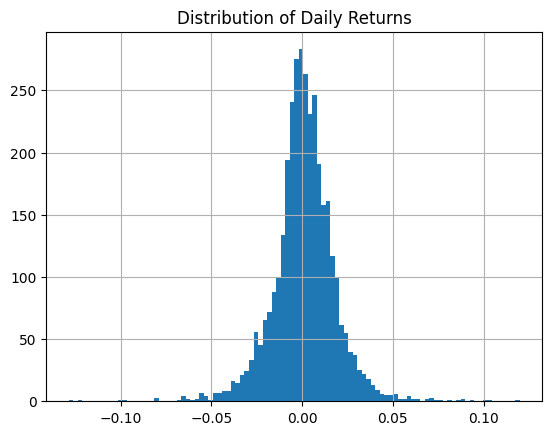

In [45]:
# Distribution of returns
returns.hist(bins=100)
plt.title("Distribution of Daily Returns")
plt.show()


---

**Question 2.** Look at the histogram of daily returns for your chosen asset. What features of the distribution stand out? Why might a business stakeholder care about these features?

---

## Feature Construction: Autoregressive Predictors

We now move from raw returns to predictive features.

In this section, we construct a simple autoregressive feature set. The idea is straightforward: Past returns may contain information about future returns. By lagging the return series, we create predictors that allow the model to learn temporal patterns.

This setup corresponds to a linear autoregressive model of the form:

$$
r_{t+1} = \beta_0 + \beta_1 r_t + \beta_2 r_{t-1} + \cdots + \beta_k r_{t-k} + \varepsilon_{t+1}.
$$

It is important to think carefully about alignment. Predictors must use only information available at time t to predict returns at time t+1. Any leakage of future information would invalidate the model evaluation.


In [46]:
data = pd.DataFrame({
    "y": returns
})

for lag in range(1,6):
    data[f"lag_{lag}"] = returns.shift(lag)

data.dropna(inplace=True)
data.head()


,y,lag_1,lag_2,lag_3,lag_4,lag_5
date,,,,,,
2011-01-10,0.018847,0.007161,-0.000808,0.008180,0.005219,0.021732
2011-01-11,-0.002380,0.018847,0.007161,-0.000808,0.008180,0.005219
2011-01-12,0.008137,-0.002380,0.018847,0.007161,-0.000808,0.008180
2011-01-13,0.003658,0.008137,-0.002380,0.018847,0.007161,-0.000808
2011-01-14,0.008100,0.003658,0.008137,-0.002380,0.018847,0.007161


We can also create a few rolling window features like taking the mean return value of the last 30 days or the standard deviation of returns for the last 30 days

In [47]:
data["ma_30"] = returns.shift(1).rolling(30).mean()
data["vol_30"] = returns.shift(1).rolling(30).std()

data.dropna(inplace=True)


---

**Question 3.** What is the `.shift(1).rolling(30).mean()` doing? Why is the `shift(1)` important for building a predictive model?

---

We can also incorporate information from other assets. Here, we're taking a particularly simplistic approach.

In [48]:
market_ret = returns_matrix.mean(axis=1)

data["market_avg"] = market_ret.shift(1)
data["market_avg"].describe()

,market_avg
count,3485.000000
mean,0.000700
std,0.012188
min,-0.125042
25%,-0.004977
50%,0.001005
75%,0.006981
max,0.114677


---

**Question 4.** What does the variable `market_avg` capture?

---

## Baseline Predictive Models

We now move from feature construction to model estimation.

The baseline model is a simple linear regression that uses the autoregressive features to predict next-period returns. This corresponds to a classical time-series forecasting setup: estimate parameters using historical data and evaluate performance out-of-sample.

The workflow in this section follows a standard train–test framework:

First, the dataset is split into a training period and a testing period. The model is estimated using only the training sample. Once the parameters are fixed, predictions are generated for the testing sample.

We will be building two baseline models here. One which simply uses the previous period's return to predict the next day's return and the other which predicts returns using the 30 day moving average.

In [49]:
split_date = data.index[-252]

train = data.loc[:split_date]
test  = data.loc[split_date:]

X_train = train.drop("y", axis=1)
y_train = train["y"]

X_test = test.drop("y", axis=1)
y_test = test["y"]


---

**Question 5.** In time series settings, random train/test splits can be misleading. Explain why random selecting the train/test split could be problematic in this return forecasting context. Give two sensible alternative spltting/validation approaches beyond the simple "hold out the last year" approach taken above.

(Think about how the model might be deployed, evaluated, and updated in practice and how this might be represented by the train/test setup.)

---

## Simple baseline models

In [50]:
y_pred_naive = X_test["lag_1"]


In [51]:
y_pred_ma = test["ma_30"]


To evaluate our models, we will be using the Mean Squared Error metric.

In [53]:
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return mse

print("Naive:", evaluate(y_test, y_pred_naive))
print("MA30:", evaluate(y_test, y_pred_ma))


Naive: 0.0003787349389365079
MA30: 0.0002087410859099824


In [55]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

evaluate(y_test, y_pred_lr)


0.0002052264064653805

In [58]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)

print('Ridge Regression:', evaluate(y_test, ridge.predict(X_test)))
print('Lasso Regression:', evaluate(y_test, lasso.predict(X_test)))

Ridge Regression: 0.0002042606559377545
Lasso Regression: 0.00020333510088875532


---

**Question 6.** Provide a brief explanation of each of the baseline models. Which of the baseline models performs better according to our MSE criterion? How might one interpret the MSEs - e.g., what do these numbers tell us about the quality of the forecasts? (HINT: You might refer back to the summary statistics provided above.)

---

## Main Question Prompt

Your goal is now to build two prediction rules for your chosen ticker. In the first, you will continue with the exercise in trying to build a model to forecast returns. In the second, you will try to build a model to predict absolute returns. Focus on predicting a single series - the series that you started with in the preceding part of this problem.

Note that there is no single correct answer. A good solution will likely require trying several things out, comparing alternative before selecting a final approach, and making thoughtful decisions along the way.

---
**Question 7.** A prediction rule is most effective when it supports a clear business goal. Clearly state what you think a sensible objective is in this setting. Your objective should include discussion of why it might make sense to try to predict absolute returns in addition to just raw returns. Given your articulated objective, explain what performance metric(s) you focus on and justify these choices.

---

**Question 8.** Build and compare models beyond the baselines provided above. These models could include additional features constructed from the chosen asset of the universe of provided assets. You can (and should) consider different types of models for returns and absolute returns. Clearly articulate

  - the features you use,
  - how you avoid look-ahead bias/data-leakage
  - how you choose tuning parameters
  - why your final models are the ones you recommend.

---

**Question 9** Finally (and most importantly), prepare a slide deck suitable for a 10 minute presentation to a portfolio manager who cares about business usefulness and risk management and is skeptical of models that feel like black boxes. That is, your presentation should describe how well the model perform in business relevant terms and explain (to the extent possible) how the model makes predictions (e.g., what the important drivers of predictions are). You should also discuss caveats and potential failure modes and a recommendation for how the firm could use, monitor, and update the models.

---
---
---

# Case 2 — Purchase Prediction

##Set-up

Imagine you work on the pricing and marketing analytics team at a consumer products firm. The firm sells a premium dishwasher detergent in single-unit bottles. Each period, each household sees a price and decides whether to purchase. The firm operates across multiple U.S. states and adjusts its pricing strategy over time.

### Why Does Price Vary?

The price of the product changes over time for several realistic reasons:

- Changes in input costs (e.g., chemicals, packaging, transportation)
- Supply chain disruptions
- Macroeconomic conditions (inflation, demand shifts)
- Promotional cycles
- Strategic price experimentation

In other words, the firm does not charge a constant price. Instead, it adjusts price dynamically in response to changing economic conditions and internal cost pressures.

### Goal

Your task is to predict whether a household purchases the product at a given time, given observable characteristics and the price they face.


The data you will use are **simulated market data** generated from a demand / purchasing process designed to look realistic (heterogeneous households, price sensitivity, brand loyalty, and time-varying conditions). You should treat this as a prediction problem: build the best purchase prediction model you can using the variables the firm could plausibly observe.

---

## Data

### Observational Unit

Each row in the dataset represents a specific household in a specific period observing a specific price.

### Target (Outcome) Variable

- **`purchase`**  
  = 1 if the household purchased the detergent in that period  
  = 0 otherwise  

### Key Explanatory Variables

- **`price`**  
  The price of the product in that period.

- **`income`**  
  Household income.

- **`age`**  
  Age of the household head.

- **`family_size`**  
  Number of people in the household.

- **`prev_interactions`**  
  Number of prior interactions with the brand

- **`state`**  
  U.S. state of residence.

- **`sex`**  
  Sex of household head.

- **`race`**  
  Race category of household head.

- **`period`**  
  Time index (captures macroeconomic evolution and firm pricing adjustments).

- **`hh_id`**  
  Household identifier (used only for tracking, not prediction).


In [59]:
#Libraries for this case
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

np.random.seed(42)


## Set-up Questions

---

**Question 1.** Briefly explain what the import cell above is doing.

- Why do we import libraries before doing anything else?
- What is the purpose of setting a random seed with `np.random.seed(42)`?

---

In [60]:
# Load CSV from public Dropbox link
DROPBOX_CSV_URL = "https://www.dropbox.com/scl/fi/6ochk5xrz77inqrfm8cve/pricing_application_hh_empirical.csv?rlkey=jwn14ooz5hqwx32u4agba154y&st=fn71m3vj&dl=1"

def load_csv(url: str) -> pd.DataFrame:
    df = pd.read_csv(url)
    return df

df = load_csv(DROPBOX_CSV_URL)
df.describe()


,Unnamed: 0,period,hh_id,price,purchase,income,age,family_size,prev_interactions
count,16249.000000,16249.000000,16249.000000,16249.000000,16249.000000,16249.000000,16249.000000,16249.0,16249.000000
mean,8124.000000,24.578682,50040.177057,29.921580,0.264693,79250.880771,39.004155,3.0,0.430488
std,4690.826597,14.394311,28894.279251,1.090398,0.441183,11811.591870,11.652884,0.0,1.156983
min,0.000000,0.000000,13.000000,27.492303,0.000000,50590.511645,18.000000,3.0,0.000000
25%,4062.000000,12.000000,24922.000000,29.260322,0.000000,70718.365353,30.569045,3.0,0.000000
50%,8124.000000,25.000000,50133.000000,29.908086,0.000000,75828.908524,38.657861,3.0,0.000000
75%,12186.000000,37.000000,75235.000000,30.524700,1.000000,91522.753035,46.965912,3.0,0.000000
max,16248.000000,49.000000,99996.000000,33.119937,1.000000,103453.268505,84.596031,3.0,10.000000


We will predict `purchase` using a mix of numeric + categorical features.

We will exclude identifiers to avoid memorization:
- `hh_id` (household id)
- `period` (time index) is debatable; we keep it *optional* (students can test impact)

In [61]:
# 1. Drop common index-like columns if present
for col in ["Unnamed: 0", "index", "Index"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# 2. Ensure target exists
TARGET = "purchase"
assert TARGET in df.columns, f"Expected target column `{TARGET}` not found."

# 3. Ensure target is binary integer
df[TARGET] = df[TARGET].astype(int)

# 4. Report dataset dimensions
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

# 5. Define exclusions (avoid ID leakage)
EXCLUDE = [TARGET]
if "hh_id" in df.columns:
    EXCLUDE.append("hh_id")

# 6. Create X and y
X = df.drop(columns=[c for c in EXCLUDE if c in df.columns]).copy()
y = df[TARGET].copy()

# 7. Detect feature types automatically
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("\nNumeric columns:", num_cols)
print("Categorical columns:", cat_cols)
print("\nFeature matrix shape:", X.shape)
print("Target mean (purchase rate):", y.mean())


Number of observations: 16249
Number of variables: 11

Numeric columns: ['period', 'price', 'income', 'age', 'family_size', 'prev_interactions']
Categorical columns: ['state', 'sex', 'race']

Feature matrix shape: (16249, 9)
Target mean (purchase rate): 0.2646932118899625


---

**Question 2.** Using the summary statistics above, answer the following:

1. If a model always predicts “no purchase,” would it achieve high *accuracy*? What does this imply about which metrics you should (and should not) emphasize?
2. Describe how `price` varies in the data. Why is price variation essential for learning anything useful about demand or targeting?

---

---

**Question 3.** Why do we explicitly remove identifier-like variables such as `hh_id` from the feature matrix? What could go wrong if we allowed the model to use household IDs for prediction?

Why do we separate the dataset into `X` (features) and `y` (target) before modeling? What conceptual mistake would we make if `purchase` were accidentally included in `X`?

---   

### Randomization and splits (train/validation/test)

In [62]:
# Split 1: Train/test split WITHOUT shuffling.
# This keeps the original row order
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X, y, test_size=0.25, shuffle=False
)

# Split 2: Train/test split WITH shuffling + stratification.
# - shuffle=True randomizes the row order before splitting, so train/test are more comparable.
# - random_state=42 makes the split reproducible (same split each time you run).
# - stratify=y preserves the overall purchase rate (class balance) in both train and test sets.
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.25, shuffle=True, random_state=42, stratify=y
)

# Helper function to summarize a split by checking whether the class balance
# is satisfied
def summarize(y_tr, y_te, name):
    print(f"\n{name}")
    print("Train purchase rate:", y_tr.mean(), "| n=", len(y_tr))
    print("Test  purchase rate:", y_te.mean(), "| n=", len(y_te))

summarize(y_train_ns, y_test_ns, "No shuffle")
summarize(y_train_s, y_test_s, "Shuffle + stratify")



No shuffle
Train purchase rate: 0.2776136550139504 | n= 12186
Test  purchase rate: 0.22594142259414227 | n= 4063

Shuffle + stratify
Train purchase rate: 0.26473001805350405 | n= 12186
Test  purchase rate: 0.26458282057592913 | n= 4063


In [63]:
# Use the shuffled split as standard
X_train_full, X_test, y_train_full, y_test = X_train_s, X_test_s, y_train_s, y_test_s

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Purchasing rates:", y_train.mean(), y_val.mean(), y_test.mean())


Train: (9139, 9) Val: (3047, 9) Test: (4063, 9)
Purchasing rates: 0.2646897910055805 0.2648506727929111 0.26458282057592913


---

**Question 4.** Why do we create separate train/validation/test splits. In the data, there is a `period` variable. Here, we are randomizing by independently sampling ignoring the presence of this variable. Explain circumstances where this splitting regime is sensible and provide an example of a circumstance where it may be a bad idea.

---

### Baseline model: Logistic regression

In [64]:
# ColumnTransformer allows us to apply different preprocessing
# steps to different types of variables (numeric vs categorical).

preprocess = ColumnTransformer(
    transformers=[
        # 1. Standardize numeric variables:
        #    - Centers them at mean 0
        #    - Scales them to standard deviation 1
        ("num", StandardScaler(), num_cols),
        # 2. One-hot encode categorical variables
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)
# Logistic regression model
logit = LogisticRegression(max_iter=3000)

# This ensures:
#   - Preprocessing is fit only on training data
#   - The exact same transformations are applied to validation/test data
#   - No data leakage occurs
pipe_logit = Pipeline([
    ("prep", preprocess),
    ("model", logit)
])
pipe_logit.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['period', 'price', 'income',
                                                   'age', 'family_size',
                                                   'prev_interactions']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['state', 'sex', 'race'])])),
                ('model', LogisticRegression(max_iter=3000))])

In [65]:
def eval_classifier(pipe, X, y, name="set"):
    """
    Evaluate a fitted classification pipeline on a given dataset.

    Parameters:
        pipe : fitted sklearn Pipeline
        X    : feature matrix
        y    : true labels (0/1 purchase)
        name : label identifying the dataset (train/val/test)

    Returns:
        Dictionary of performance metrics.
    """
    # 1. Predict purchase probabilities.
    p = pipe.predict_proba(X)[:, 1]
    # 2. Assume individuals will purchase the product if probability >= 0.5.
    # You can modify this threshold.
    yhat = (p >= 0.5).astype(int)

    # 2. Compute evaluation metrics
    out = {
        "set": name,
        "accuracy": accuracy_score(y, yhat),                        # Fraction of correct predictions.
        "precision": precision_score(y, yhat, zero_division=0),     # Precision: Of predicted purchases, how many were correct?
        "recall": recall_score(y, yhat, zero_division=0),           # Recall: Of actual purchases, how many did we correctly identify?
        "f1": f1_score(y, yhat, zero_division=0),                   # F1: Harmonic mean of precision and recall
        "roc_auc": roc_auc_score(y, p),                             # ROC AUC: Measures ranking quality (threshold-independent).
        "log_loss": log_loss(y, p),                                 # Log loss: Measures quality of predicted probabilities.
    }
    return out

res_train = eval_classifier(pipe_logit, X_train, y_train, "train")
res_val   = eval_classifier(pipe_logit, X_val, y_val, "val")
res_test  = eval_classifier(pipe_logit, X_test, y_test, "test")

pd.DataFrame([res_train, res_val, res_test])


,set,accuracy,precision,recall,f1,roc_auc,log_loss
0,train,0.827552,0.714504,0.580405,0.640511,0.882648,0.369097
1,val,0.828684,0.725832,0.567534,0.636996,0.881605,0.372064
2,test,0.818361,0.687848,0.573953,0.625761,0.873684,0.379742


---

**Question 5.** Suppose you are the pricing manager at the detergent company.

1. Which performance metrics would you care most about (e.g., accuracy, precision, recall, ROC AUC, log loss)?  Why would those metrics matter economically?  
2. Would maximizing overall accuracy necessarily maximize profits? Explain.

Be concrete in your reasoning.

---


### From Prediction to Managerial Decisions

You have now estimated a logistic regression model predicting whether a household purchases the product.

The next two code blocks use this model to form a gain chart and look at some of the coefficients in the estimated model.



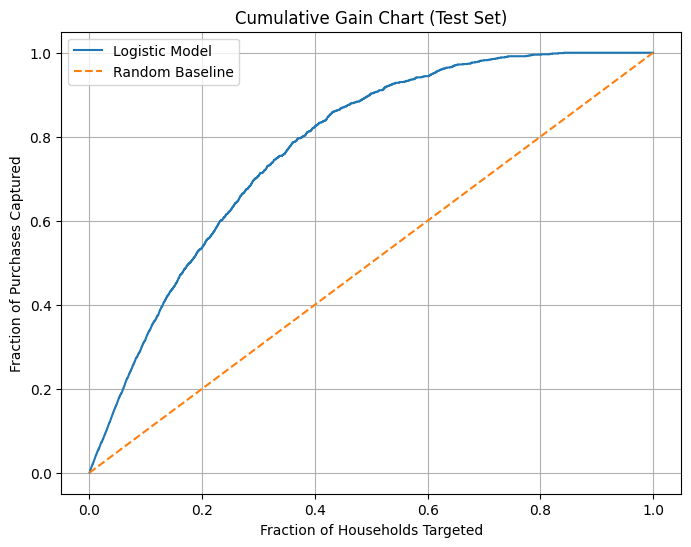

If the firm targets the top 20% of households by predicted probability,
it captures approximately 53.58% of all purchases.


In [67]:
# 1. Get predicted probabilities on test set
p_test = pipe_logit.predict_proba(X_test)[:, 1]

# 2. Create dataframe for sorting
gain_df = (
    pd.DataFrame({
        "y_true": y_test.values,
        "p_hat": p_test
    })
    .sort_values("p_hat", ascending=False)
    .reset_index(drop=True)
)

# 3. Compute cumulative metrics
gain_df["cum_samples"] = np.arange(1, len(gain_df) + 1) / len(gain_df)
gain_df["cum_positives"] = gain_df["y_true"].cumsum()
total_positives = gain_df["y_true"].sum()
gain_df["cum_gain"] = gain_df["cum_positives"] / total_positives

# 4. Plot cumulative gain curve
plt.figure(figsize=(8,6))
plt.plot(gain_df["cum_samples"], gain_df["cum_gain"], label="Logistic Model")
plt.plot([0,1], [0,1], linestyle="--", label="Random Baseline")

plt.xlabel("Fraction of Households Targeted")
plt.ylabel("Fraction of Purchases Captured")
plt.title("Cumulative Gain Chart (Test Set)")
plt.legend()
plt.grid(True)
plt.show()

# 5. Managerial summary example: Top 20%
top_20_index = int(0.20 * len(gain_df))
top_20_capture = gain_df.loc[top_20_index, "cum_gain"]

print(f"If the firm targets the top 20% of households by predicted probability,")
print(f"it captures approximately {top_20_capture:.2%} of all purchases.")

In [ ]:
# --- Simple interpretation: largest logistic regression coefficients ---

# Extract feature names after preprocessing
feat_names = pipe_logit.named_steps["prep"].get_feature_names_out()
coefs = pipe_logit.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs})
coef_df = coef_df.sort_values("coef")

print("Most negative coefficients (lower purchase propensity):")
display(coef_df.head(10))

print("\nMost positive coefficients (higher purchase propensity):")
display(coef_df.tail(10))


---

**Question 6.** Use the logistic regression baseline and the associated gain chart.

- How would you use the gain chart to explain (in plain language) whether the model adds value over random targeting?
- What is one reason a model with a better ROC AUC might still be *worse* for the firm's operational objective?
- Which variables appear most influential in predicting purchase? Do they make sense? Explain.



## Main Question Prompt

Your goal is to build the most effective prediction rule for `purchase` that you can.

There is no single correct answer. A strong solution will articulate a clear business objective, choose evaluation metrics aligned with that objective, compare multiple models and tuning choices, and communicate the result clearly to a manager.

---

**Question 6.** Expand away from the logistic regression baseline. Build and compare at least **two** additional prediction rules (e.g., regularized logistic regression, decision trees, random forests, gradient boosting, kNN, or another method). Be explicit about preprocessing choices, hyperparameter tuning (validation set or cross-validation), and why the model you select is the best fit for your objective.

---

**Question 7.** Finally (and most importantly), prepare a slide deck suitable for a 10 minute presentation suitable for a **10-minute** presentation to a pricing/marketing manager who cares about business outcomes, is wary of opaque black-box solutions, and wants to understand risks and trade-offs.

Your deck should include
1. The business objective and how the model would be used operationally.
2. How you evaluated performance (in business terms).
3. Key results (illustrating how the model supports your objective).
4. What seems to drive predictions (interpretability at the right level).
5. Discussion of risks and caveats.
